# Experiment 1: NGRC Weight Analysis on the Lorenz System

## Objectives

- Generate Lorenz system data and train an NGRC model with $k = 1$.
- Extract and examine the learned NGRC weights.
- Identify the most influential linear and nonlinear features.
- Compare the learned terms with the Euler-discretized Lorenz equations.
- Investigate whether NGRC recovers the known dynamical structure of the Lorenz system.
- Visualize and interpret the dominant interactions governing the system dynamics.

In [1]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path


In [2]:
# Output directories

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "lrz63"

LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR.mkdir(parents=True, exist_ok=True)

## Simulation and NVAR Parameters

In [3]:
def run_experiment(dt=0.025, ridge_param=2.5e-6, k=1):

    # Parameters

    warmup = 5.0
    traintime = 10.0
    testtime = 120.0
    lyaptime = 1.104

    maxtime = warmup + traintime + testtime

    warmup_pts = round(warmup / dt)
    traintime_pts = round(traintime / dt)
    warmtrain_pts = warmup_pts + traintime_pts
    testtime_pts = round(testtime / dt)
    maxtime_pts = round(maxtime / dt)
    lyaptime_pts = round(lyaptime / dt)

    # NVAR dimensions

    d = 3

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    t_eval = np.linspace(0, maxtime, maxtime_pts + 1)

    # Lorenz system

    sigma = 10
    beta = 8 / 3
    rho = 28

    def lorenz(t, state):

        x, y, z = state

        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        return [dx, dy, dz]

    lorenz_soln = solve_ivp(
        lorenz,
        (0, maxtime),
        [
            17.67715816276679,
            12.931379185960404,
            43.91404334248268,
        ],
        t_eval=t_eval,
        method="RK23",
    )

    total_var = np.var(lorenz_soln.y)

    # Linear features

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):
        for j in range(delay, maxtime_pts):
            x[d * delay:d * (delay + 1), j] = lorenz_soln.y[:, j - delay]

    # Training feature matrix

    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin + 1, :] = x[:, warmup_pts - 1:warmtrain_pts - 1]

    cnt = 0

    for i in range(dlin):
        for j in range(i, dlin):

            out_train[dlin + 1 + cnt, :] = (
                x[i, warmup_pts - 1:warmtrain_pts - 1]
                * x[j, warmup_pts - 1:warmtrain_pts - 1]
            )

            cnt += 1

    # Training target

    Y = (
        x[0:d, warmup_pts:warmtrain_pts]
        - x[0:d, warmup_pts - 1:warmtrain_pts - 1]
    )

    # Ridge regression

    W_out = (
        Y @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param * np.identity(dtot)
        )
    )

    # Training prediction

    x_predict = (
        x[0:d, warmup_pts - 1:warmtrain_pts - 1]
        + W_out @ out_train
    )

    train_nrmse = np.sqrt(
        np.mean(
            (
                x[0:d, warmup_pts:warmtrain_pts]
                - x_predict
            ) ** 2
        ) / total_var
    )

    # Autonomous prediction

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))

    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):
            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        x_test[d:dlin, j + 1] = x_test[0:(dlin - d), j]

        x_test[0:d, j + 1] = (
            x_test[0:d, j]
            + W_out @ out_test
        )

    # Test NRMSE

    true_segment = x[
        0:d,
        warmtrain_pts - 1:warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        0:d,
        0:lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        ) / total_var
    )

    return {
        "dt": dt,
        "k": k,
        "ridge": ridge_param,
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "W_out": W_out,
        "x_test": x_test,
        "true_test": x[
            0:d,
            warmtrain_pts - 1:warmtrain_pts + testtime_pts - 1,
        ],
    }

In [4]:
def build_labels(d=3, k=1):

    variables = ["x", "y", "z"]

    linear_labels = []

    for delay in range(k):
        for var in variables:

            if delay == 0:
                linear_labels.append(f"{var}(t)")
            else:
                linear_labels.append(f"{var}(t-{delay})")

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):
           labels.append(f"{linear_labels[i]}*{linear_labels[j]}")

    return labels

In [5]:
labels = build_labels(d=3, k=1)

dt_values = [
    0.001,
    0.0025,
    0.005,
    0.01,
    0.025,
    0.05,
    0.06,
    0.07,
    0.08,
    0.09,
    0.1,
]

results = []

for dt in dt_values:

    result = run_experiment(dt=dt, ridge_param=2.5e-6, k=1)

    results.append(result)

print(f"Completed {len(results)} runs")

Completed 11 runs


In [6]:
rows = []

for result in results:

    W = result["W_out"]

    for eq, equation in enumerate(["dx", "dy", "dz"]):

        row = {
            "dt": result["dt"],
            "equation": equation,
            "train_nrmse": result["train_nrmse"],
            "test_nrmse": result["test_nrmse"],
        }

        for i, label in enumerate(labels):
            row[label] = W[eq, i]

        rows.append(row)

weights_df = pd.DataFrame(rows)

#weights_df.to_csv("weights_analysis_k1_dt_study.csv", index=False)

weights_df.head()

,dt,equation,train_nrmse,test_nrmse,1,x(t),y(t),z(t),x(t)*x(t),x(t)*y(t),x(t)*z(t),y(t)*y(t),y(t)*z(t),z(t)*z(t)
0,0.0010,dx,0.000014,0.013306,-0.000144,-0.009797,0.009963,0.000019,0.000002,-6.725178e-07,-0.000005,-3.584714e-07,-8.937225e-07,-5.203668e-07
1,0.0010,dy,0.000014,0.013306,0.000201,0.027728,-0.000729,-0.000032,-0.000003,2.392532e-06,-0.000989,-3.008623e-07,-1.362867e-05,8.190303e-07
2,0.0010,dz,0.000014,0.013306,-0.001098,-0.000048,0.000030,-0.002540,0.000005,9.757848e-04,0.000001,1.637346e-05,-8.081401e-07,-3.222389e-06
3,0.0025,dx,0.000061,0.023706,-0.000350,-0.023802,0.024718,0.000045,0.000004,-1.601096e-06,-0.000032,-8.899000e-07,-2.828537e-06,-1.262012e-06
4,0.0025,dy,0.000061,0.023706,0.001045,0.068566,-0.001089,-0.000151,-0.000012,8.222206e-06,-0.002441,-8.125052e-07,-7.112888e-05,3.672440e-06


In [7]:
weights_dx = weights_df[ weights_df["equation"] == "dx" ].copy()

# Normalize learned coefficients
weights_dx["NGRC x(t)/dt"] = weights_dx["x(t)"] / weights_dx["dt"]
weights_dx["NGRC y(t)/dt"] = weights_dx["y(t)"] / weights_dx["dt"]

# Continuous-time Lorenz coefficients
weights_dx["Euler x(t)/dt"] = -10
weights_dx["Euler y(t)/dt"] = 10

weights_dx[[
    "dt",
    "NGRC x(t)/dt",
    "Euler x(t)/dt",
    "NGRC y(t)/dt",
    "Euler y(t)/dt",
]].head()

,dt,NGRC x(t)/dt,Euler x(t)/dt,NGRC y(t)/dt,Euler y(t)/dt
0,0.0010,-9.796535,-10,9.963497,10
3,0.0025,-9.520779,-10,9.887032,10
6,0.0050,-9.074172,-10,9.767808,10
9,0.0100,-8.230818,-10,9.560165,10
12,0.0250,-6.110286,-10,9.175140,10


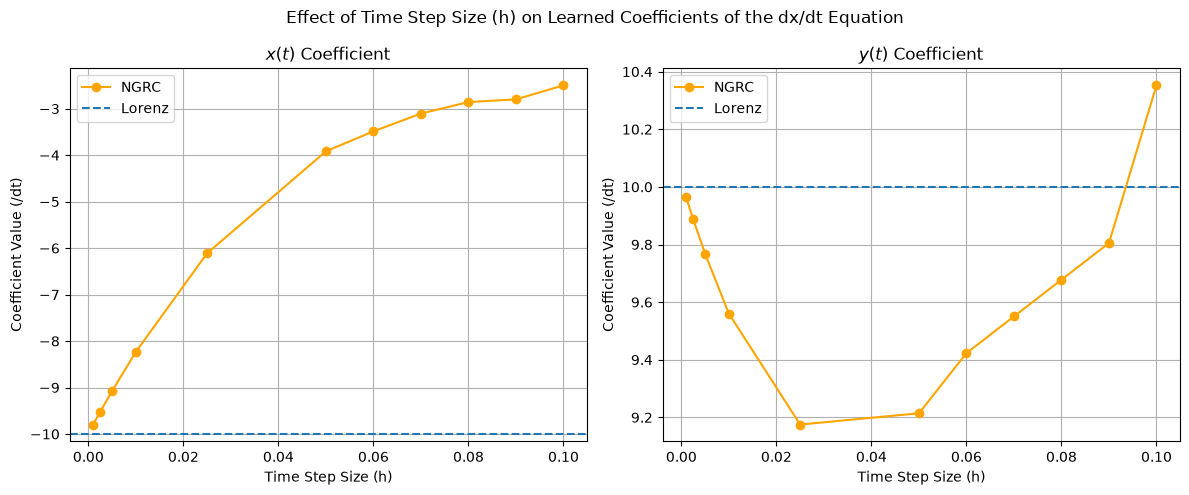

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# x coefficient
axes[0].plot(
    weights_dx["dt"],
    weights_dx["x(t)"] / weights_dx["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=-10, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)$ Coefficient")
axes[0].set_xlabel("Time Step Size (h)")
axes[0].set_ylabel("Coefficient Value (/dt)")
axes[0].grid(True)
axes[0].legend()

# y coefficient
axes[1].plot(
    weights_dx["dt"],
    weights_dx["y(t)"] / weights_dx["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=10, linestyle="--", label="Lorenz")

axes[1].set_title(r"$y(t)$ Coefficient")
axes[1].set_xlabel("Time Step Size (h)")
axes[1].set_ylabel("Coefficient Value (/dt)")
axes[1].grid(True)
axes[1].legend()

plt.suptitle(
    "Effect of Time Step Size (h) on Learned Coefficients of the dx/dt Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dx_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [9]:
weights_dy = weights_df[ weights_df["equation"] == "dy" ].copy()

# Lorenz coefficients
weights_dy["Lorenz x(t)"] = 28
weights_dy["Lorenz y(t)"] = -1
weights_dy["Lorenz x(t)*z(t)"] = -1

weights_dy[
    [
        "dt",
        "x(t)",
        "Lorenz x(t)",
        "y(t)",
        "Lorenz y(t)",
        "x(t)*z(t)",
        "Lorenz x(t)*z(t)",
    ]
]

,dt,x(t),Lorenz x(t),y(t),Lorenz y(t),x(t)*z(t),Lorenz x(t)*z(t)
1,0.0010,0.027728,28,-0.000729,-1,-0.000989,-1
4,0.0025,0.068566,28,-0.001089,-1,-0.002441,-1
7,0.0050,0.134482,28,0.000309,-1,-0.004773,-1
10,0.0100,0.257415,28,0.010838,-1,-0.009085,-1
13,0.0250,0.542196,28,0.105894,-1,-0.018868,-1
16,0.0500,0.705084,28,0.449861,-1,-0.024104,-1
19,0.0600,0.660854,28,0.636948,-1,-0.022489,-1
22,0.0700,0.616892,28,0.788176,-1,-0.020703,-1
25,0.0800,0.549942,28,0.924652,-1,-0.018272,-1
28,0.0900,0.410777,28,1.066063,-1,-0.013764,-1


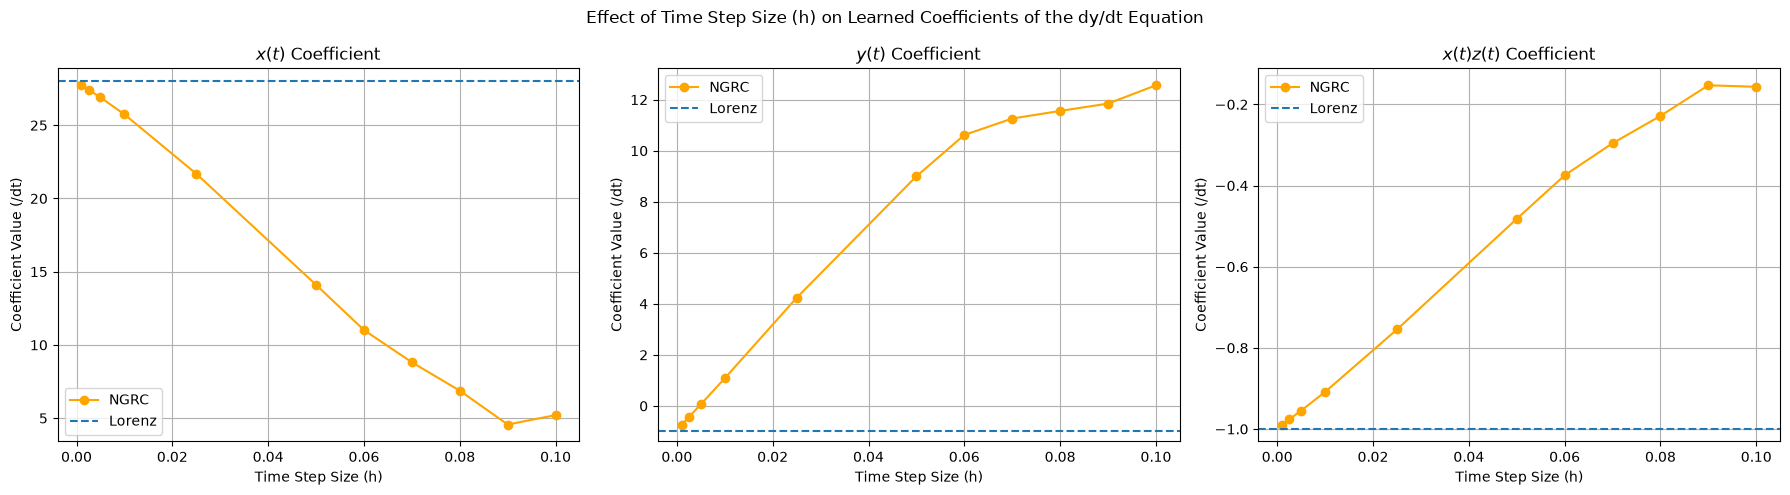

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# x coefficient
axes[0].plot(
    weights_dy["dt"],
    weights_dy["x(t)"] / weights_dy["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=28, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)$ Coefficient")
axes[0].set_xlabel("Time Step Size (h)")
axes[0].set_ylabel("Coefficient Value (/dt)")
axes[0].grid(True)
axes[0].legend()

# y coefficient
axes[1].plot(
    weights_dy["dt"],
    weights_dy["y(t)"] / weights_dy["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-1, linestyle="--", label="Lorenz")

axes[1].set_title(r"$y(t)$ Coefficient")
axes[1].set_xlabel("Time Step Size (h)")
axes[1].set_ylabel("Coefficient Value (/dt)")
axes[1].grid(True)
axes[1].legend()

# xz coefficient
axes[2].plot(
    weights_dy["dt"],
    weights_dy["x(t)*z(t)"] / weights_dy["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[2].axhline(y=-1, linestyle="--", label="Lorenz")

axes[2].set_title(r"$x(t)z(t)$ Coefficient")
axes[2].set_xlabel("Time Step Size (h)")
axes[2].set_ylabel("Coefficient Value (/dt)")
axes[2].grid(True)
axes[2].legend()

plt.suptitle(
    "Effect of Time Step Size (h) on Learned Coefficients of the dy/dt Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dy_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [11]:
weights_dz = weights_df[ weights_df["equation"] == "dz" ].copy()

# Lorenz coefficients
weights_dz["Lorenz x(t)*y(t)"] = 1
weights_dz["Lorenz z(t)"] = -(8 / 3)

weights_dz[
    [
        "dt",
        "x(t)*y(t)",
        "Lorenz x(t)*y(t)",
        "z(t)",
        "Lorenz z(t)",
    ]
]

,dt,x(t)*y(t),Lorenz x(t)*y(t),z(t),Lorenz z(t)
2,0.0010,0.000976,1,-0.002540,-2.666667
5,0.0025,0.002370,1,-0.006074,-2.666667
8,0.0050,0.004492,1,-0.011193,-2.666667
11,0.0100,0.007889,1,-0.018318,-2.666667
14,0.0250,0.009793,1,-0.012312,-2.666667
17,0.0500,-0.018932,1,0.079019,-2.666667
20,0.0600,-0.040439,1,0.125772,-2.666667
23,0.0700,-0.060845,1,0.142862,-2.666667
26,0.0800,-0.085766,1,0.161810,-2.666667
29,0.0900,-0.101348,1,0.147107,-2.666667


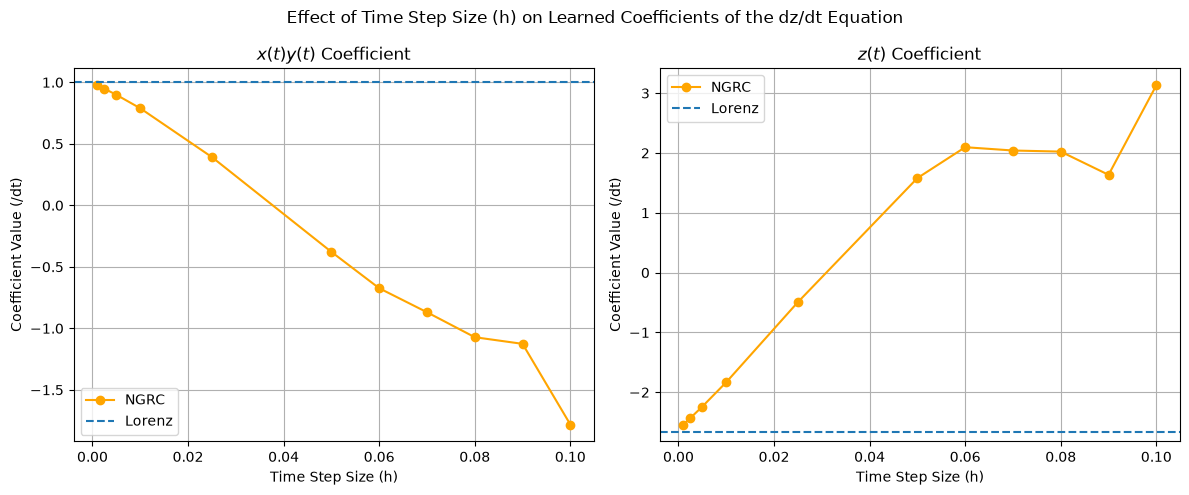

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# xy coefficient
axes[0].plot(
    weights_dz["dt"],
    weights_dz["x(t)*y(t)"] / weights_dz["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=1, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)y(t)$ Coefficient")
axes[0].set_xlabel("Time Step Size (h)")
axes[0].set_ylabel("Coefficient Value (/dt)")
axes[0].grid(True)
axes[0].legend()

# z coefficient
axes[1].plot(
    weights_dz["dt"],
    weights_dz["z(t)"] / weights_dz["dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-(8 / 3), linestyle="--", label="Lorenz")

axes[1].set_title(r"$z(t)$ Coefficient")
axes[1].set_xlabel("Time Step Size (h)")
axes[1].set_ylabel("Coefficient Value (/dt)")
axes[1].grid(True)
axes[1].legend()

plt.suptitle(
    "Effect of Time Step Size (h) on Learned Coefficients of the dz/dt Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dz_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [13]:
weights_dx = weights_df[
    weights_df["equation"] == "dx"
].copy()

factor_cols = labels[1:]   # exclude bias

rows = []

for _, row in weights_dx.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dx = (
    pd.DataFrame(rows)
    .sort_values("dt")
)

top3_dx

,dt,1st,2nd,3rd
0,0.0010,y(t) (9.96),x(t) (-9.80),z(t) (0.02)
1,0.0025,y(t) (9.89),x(t) (-9.52),z(t) (0.02)
2,0.0050,y(t) (9.77),x(t) (-9.07),x(t)*z(t) (-0.02)
3,0.0100,y(t) (9.56),x(t) (-8.23),x(t)*z(t) (-0.05)
4,0.0250,y(t) (9.18),x(t) (-6.11),x(t)*z(t) (-0.10)
5,0.0500,y(t) (9.21),x(t) (-3.92),z(t) (-0.27)
6,0.0600,y(t) (9.42),x(t) (-3.49),z(t) (-0.39)
7,0.0700,y(t) (9.55),x(t) (-3.10),z(t) (-0.79)
8,0.0800,y(t) (9.68),x(t) (-2.86),z(t) (-0.97)
9,0.0900,y(t) (9.81),x(t) (-2.80),z(t) (-1.29)


In [14]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

factor_cols = labels[1:]   # exclude bias

rows = []

for _, row in weights_dy.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dy = (
    pd.DataFrame(rows)
    .sort_values("dt")
)

top3_dy

,dt,1st,2nd,3rd
0,0.0010,x(t) (27.73),x(t)*z(t) (-0.99),y(t) (-0.73)
1,0.0025,x(t) (27.43),x(t)*z(t) (-0.98),y(t) (-0.44)
2,0.0050,x(t) (26.90),x(t)*z(t) (-0.95),z(t) (-0.11)
3,0.0100,x(t) (25.74),y(t) (1.08),x(t)*z(t) (-0.91)
4,0.0250,x(t) (21.69),y(t) (4.24),z(t) (-0.80)
5,0.0500,x(t) (14.10),y(t) (9.00),z(t) (-2.19)
6,0.0600,x(t) (11.01),y(t) (10.62),z(t) (-2.62)
7,0.0700,y(t) (11.26),x(t) (8.81),z(t) (-4.39)
8,0.0800,y(t) (11.56),x(t) (6.87),z(t) (-4.77)
9,0.0900,y(t) (11.85),z(t) (-5.89),x(t) (4.56)


In [15]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

factor_cols = labels[1:]   # exclude bias

rows = []

for _, row in weights_dz.iterrows():

    dt = row["dt"]

    coeffs = row[factor_cols] / dt

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": dt,

        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",

        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",

        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dz = (
    pd.DataFrame(rows)
    .sort_values("dt")
)

top3_dz

,dt,1st,2nd,3rd
0,0.0010,z(t) (-2.54),x(t)*y(t) (0.98),x(t) (-0.05)
1,0.0025,z(t) (-2.43),x(t)*y(t) (0.95),x(t) (-0.09)
2,0.0050,z(t) (-2.24),x(t)*y(t) (0.90),x(t) (-0.16)
3,0.0100,z(t) (-1.83),x(t)*y(t) (0.79),x(t) (-0.31)
4,0.0250,x(t) (-0.86),y(t) (0.54),z(t) (-0.49)
5,0.0500,x(t) (-2.00),z(t) (1.58),y(t) (1.18)
6,0.0600,x(t) (-2.78),z(t) (2.10),y(t) (1.63)
7,0.0700,x(t) (-2.32),z(t) (2.04),y(t) (1.02)
8,0.0800,x(t) (-3.23),z(t) (2.02),y(t) (1.49)
9,0.0900,x(t) (-2.11),z(t) (1.63),x(t)*y(t) (-1.13)


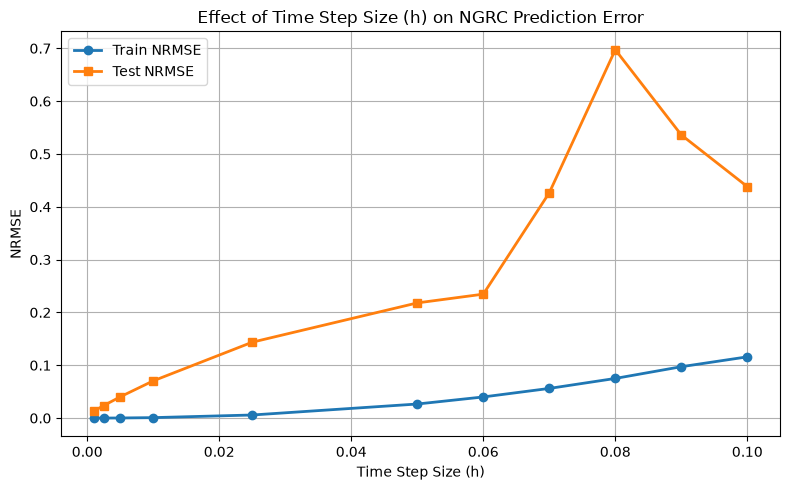

In [16]:
summary = pd.DataFrame([
    {
        "dt": r["dt"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results
])

summary = summary.sort_values("dt")

plt.figure(figsize=(8, 5))

plt.plot(
    summary["dt"],
    summary["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.plot(
    summary["dt"],
    summary["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel("Time Step Size (h)")
plt.ylabel("NRMSE")

plt.title(
    "Effect of Time Step Size (h) on NGRC Prediction Error"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [17]:
def euler_predict(
    x0,
    dt,
    testtime_pts,
    sigma=10,
    beta=8 / 3,
    rho=28,
):

    x_euler = np.zeros((3, testtime_pts))

    x_euler[:, 0] = x0

    for j in range(testtime_pts - 1):

        x_now = x_euler[0, j]
        y_now = x_euler[1, j]
        z_now = x_euler[2, j]

        dx = sigma * (y_now - x_now)
        dy = x_now * (rho - z_now) - y_now
        dz = x_now * y_now - beta * z_now

        x_euler[0, j + 1] = x_now + dt * dx
        x_euler[1, j + 1] = y_now + dt * dy
        x_euler[2, j + 1] = z_now + dt * dz

    return x_euler

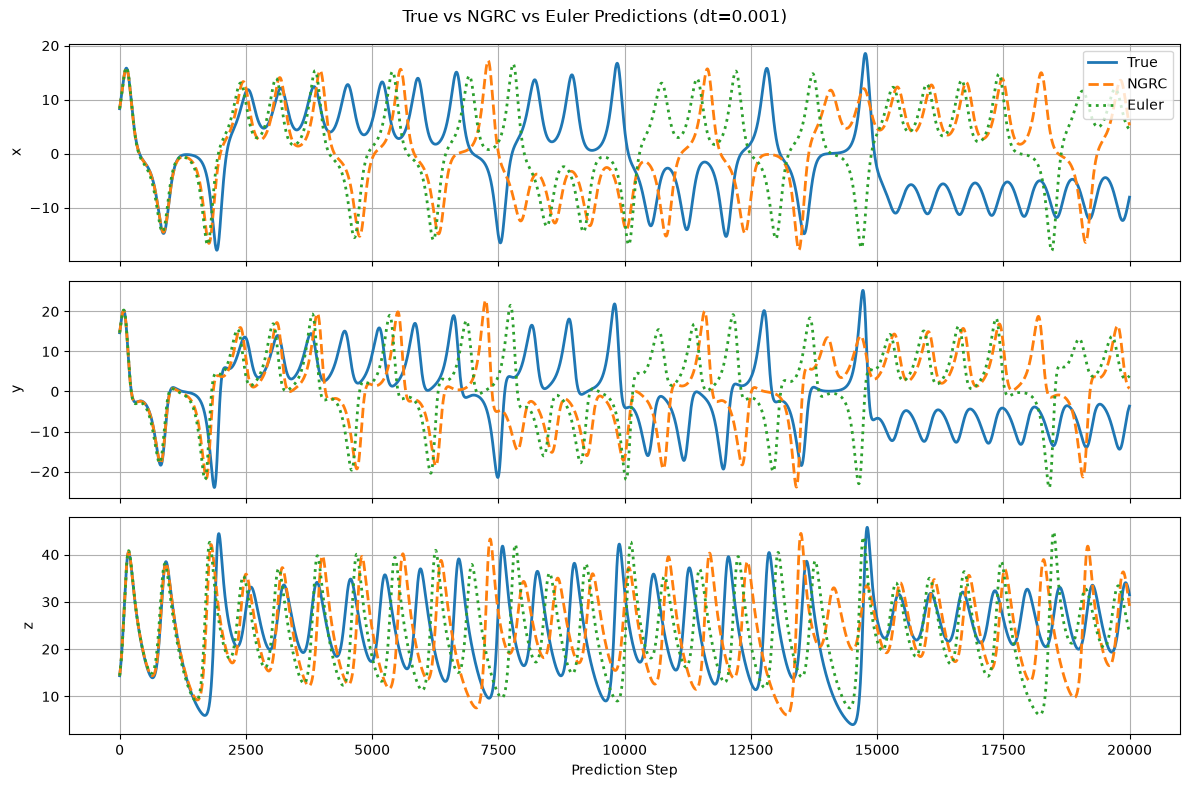

In [18]:
r = results[0]  # choose dt

true = r["true_test"]
pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = min(20000, pred_ngrc.shape[1])

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

names = ["x", "y", "z"]

for i in range(3):

    axs[i].plot(
        true[i, :n],
        linewidth=2,
        label="True",
    )

    axs[i].plot(
        pred_ngrc[i, :n],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i].plot(
        x_euler[i, :n],
        ":",
        linewidth=2,
        label="Euler",
    )

    axs[i].set_ylabel(names[i])
    axs[i].grid(True)

axs[0].legend(loc="upper right")

axs[-1].set_xlabel("Prediction Step")

plt.suptitle(
    f"True vs NGRC vs Euler Predictions (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/true_vs_ngrc_vs_euler.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

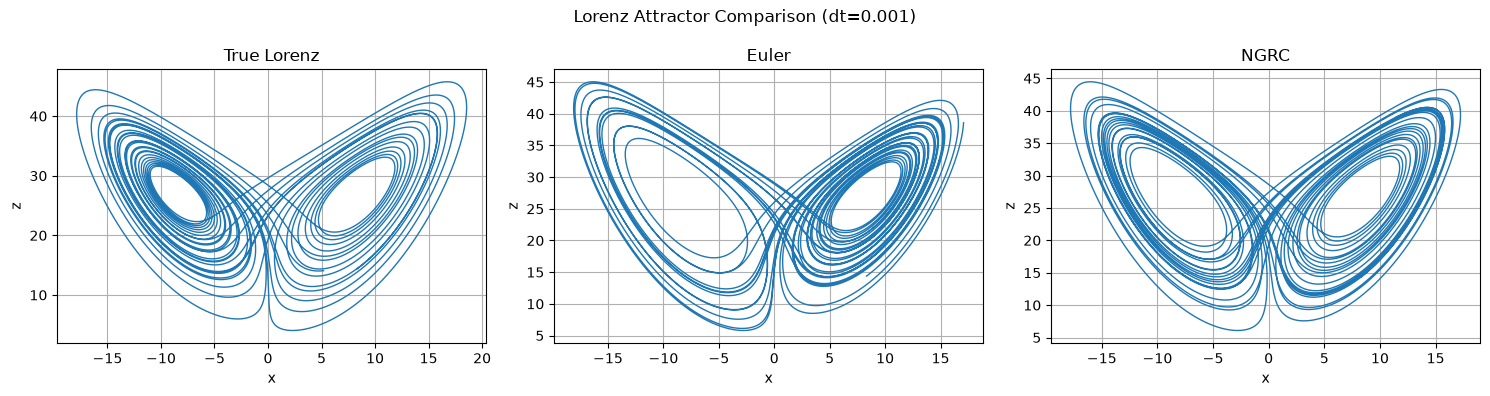

In [19]:
r = results[0]  # choose dt

true = r["true_test"]
pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = min(30000, pred_ngrc.shape[1])

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# True Lorenz
axs[0].plot(
    true[0, :n],
    true[2, :n],
    linewidth=1,
)

axs[0].set_title("True Lorenz")
axs[0].set_xlabel("x")
axs[0].set_ylabel("z")
axs[0].grid(True)

# Euler
axs[1].plot(
    x_euler[0, :n],
    x_euler[2, :n],
    linewidth=1,
)

axs[1].set_title("Euler")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")
axs[1].grid(True)

# NGRC
axs[2].plot(
    pred_ngrc[0, :n],
    pred_ngrc[2, :n],
    linewidth=1,
)

axs[2].set_title("NGRC")
axs[2].set_xlabel("x")
axs[2].set_ylabel("z")
axs[2].grid(True)

plt.suptitle(
    f"Lorenz Attractor Comparison (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

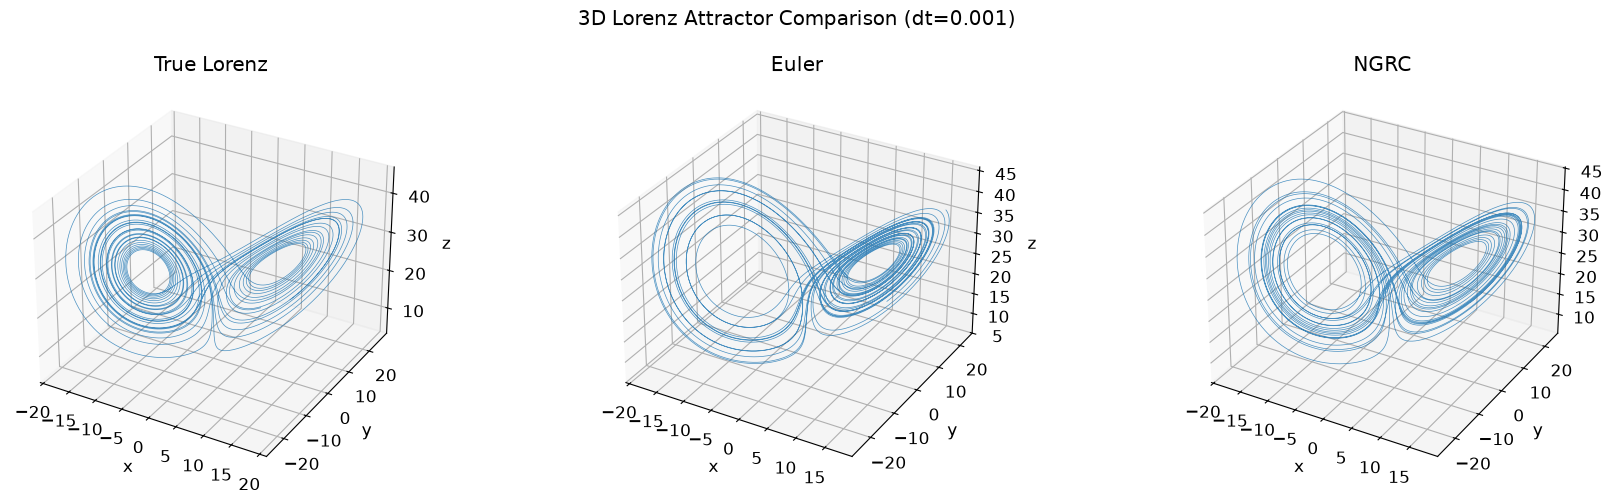

In [20]:
plt.rcParams.update({"font.size": 12})

r = results[0]  # choose dt

true = r["true_test"]
pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = min(30000, pred_ngrc.shape[1])

fig = plt.figure(figsize=(18, 5))

# True Lorenz
ax1 = fig.add_subplot(131, projection="3d")

ax1.plot(
    true[0, :n],
    true[1, :n],
    true[2, :n],
    linewidth=0.5,
    alpha=0.8,
)

ax1.set_title("True Lorenz")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# Euler
ax2 = fig.add_subplot(132, projection="3d")

ax2.plot(
    x_euler[0, :n],
    x_euler[1, :n],
    x_euler[2, :n],
    linewidth=0.5,
    alpha=0.8,
)

ax2.set_title("Euler")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

# NGRC
ax3 = fig.add_subplot(133, projection="3d")

ax3.plot(
    pred_ngrc[0, :n],
    pred_ngrc[1, :n],
    pred_ngrc[2, :n],
    linewidth=0.5,
    alpha=0.8,
)

ax3.set_title("NGRC")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

plt.suptitle(
    f"3D Lorenz Attractor Comparison (dt={r['dt']})"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_3d_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [21]:
labels = build_labels(d=3, k=1)

ridge_values = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100,
]

results_ridge = []

for ridge in ridge_values:

    result = run_experiment(dt=0.01, ridge_param=ridge, k=1)

    results_ridge.append(result)

summary_ridge = pd.DataFrame([
    {
        "ridge": r["ridge"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results_ridge
])

summary_ridge

,ridge,train_nrmse,test_nrmse
0,0.000000e+00,0.000867,0.070497
1,1.000000e-08,0.000867,0.070497
2,1.000000e-07,0.000867,0.070497
3,1.000000e-06,0.000867,0.070497
4,1.000000e-05,0.000867,0.070497
5,1.000000e-04,0.000867,0.070496
6,1.000000e-03,0.000867,0.070489
7,1.000000e-02,0.000867,0.070415
8,1.000000e-01,0.000867,0.069688
9,1.000000e+00,0.000868,0.063514


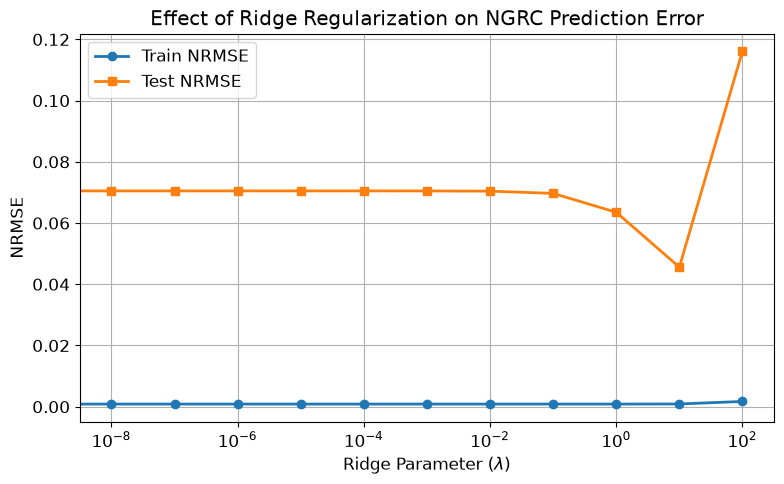

In [22]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Ridge Parameter ($\lambda$)")
plt.ylabel("NRMSE")

plt.title(
    "Effect of Ridge Regularization on NGRC Prediction Error"
)

plt.grid(True, which="both")
plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_ridge.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()